In [1]:
import earthkit.data
import earthkit.plots
from polytope.api import Client
import os

In [2]:
# Set True if you want to make a live request for the data, or false if you want to use the cached grib file
LIVE_REQUEST = True

In [3]:
request = {
    'class': 'd1',
    'dataset': 'on-demand-extremes-dt',
    'expver': '0099',
    'stream': 'oper',
    'date': '20250616',
    'time': 0,
    'type': 'fc',
    'levtype': 'sfc',
    'georef': 'u4usq2',
    'step': 12,
    'param': 167
}

In [4]:
data_file = "data/on-demands-extreme-dt-example.grib"
if not os.path.exists("data"):
    os.mkdir("data")

if LIVE_REQUEST:
    data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)
    data.to_target("file", data_file)
else:
    data = earthkit.data.from_source("file", data_file)

2026-01-20 14:49:13 - INFO - Key read from /home/jovyan/.polytopeapirc
2026-01-20 14:49:13 - INFO - Sending request...
{'request': 'class: d1\n'
            'dataset: on-demand-extremes-dt\n'
            "date: '20250616'\n"
            'expver: 0099\n'
            'georef: u4usq2\n'
            'levtype: sfc\n'
            'param: 167\n'
            'step: 12\n'
            'stream: oper\n'
            'time: 0\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-01-20 14:49:13 - INFO - Polytope user key found in session cache for user jovyan
2026-01-20 14:49:14 - INFO - Request accepted. Please poll ./f6e3ef71-c8f8-4047-9796-8568da79473e for status
2026-01-20 14:49:14 - INFO - Polytope user key found in session cache for user jovyan
2026-01-20 14:49:14 - INFO - Checking request status (f6e3ef71-c8f8-4047-9796-8568da79473e)...
2026-01-20 14:49:14 - INFO - The current status of the request is 'queued'
2026-01-20 14:49:15 - INFO - The current status of the request is 'processing'
2026

In [5]:
data.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
0,ecmf,2t,heightAboveGround,2,20250616,0,12,fc,None,lambert_lam


/opt/polytope_env/lib/python3.11/site-packages/earthkit/plots/components/subplots.py:1392: UserWarning: block is deprecated and will be removed in a future release. Please use grid_cells instead.
  warnings.warn(


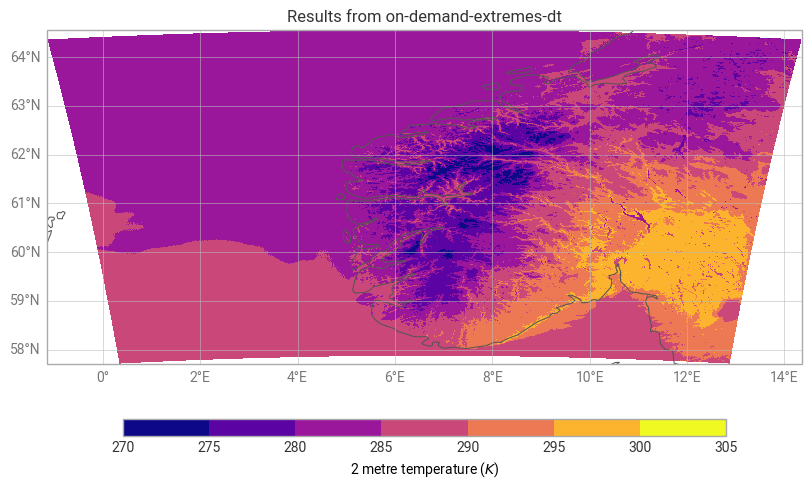

In [6]:
chart = earthkit.plots.Map()
chart.block(data)
chart.title(f"Results from on-demand-extremes-dt")
chart.coastlines()
chart.gridlines()
chart.legend()
chart.show()